# Station Information

* Station name: BLELHAM BECK_FOOTBRIDGE_E_202303
* Water Quality Data link: https://environment.data.gov.uk/hydrology/station/E02614A

## 0. Import the Relevant Libraries

In [1]:
# Import the relevant libraries
import pandas as pd
import numpy as np
import urllib.request
from pathlib import Path
import io
from sklearn.preprocessing import MinMaxScaler
import torch
import matplotlib.pyplot as plt

## 1. Import Base Classes and Helper Functions from the Project GitHub and Set Random Seeds

In [2]:
# Import the Base Classes and Helper Functions from the Project GitHub
url = "https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction//main/base_classes_and_helper_functions.py"

file_path = Path("base_classes_and_helper_functions.py")
if not file_path.exists():
    urllib.request.urlretrieve(url, file_path)
import base_classes_and_helper_functions as bchf

In [3]:
# Set the random seed for all PRNGs to ensure reproducibility
bchf.set_random_seed()

## 2. Load the Raw Data from the Project GitHub into a Pandas DataFrame

In [4]:
    # Create the path to the directory containing the data in the Jupyter notebook environment
    data_path = bchf.load_raw_data(url="https://github.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/raw/main/data/processed_data/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_preprocessed_data.zip")

    # Assign the full filepath for the preprocessed data
    parameter_path = "/content" / data_path / "BLELHAM BECK_FOOTBRIDGE_E_202303_preprocessed_data.csv"

[INFO] data/raw_data directory has been created.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [5]:
# Load the data into a Pandas DataFrame
df_parameters = pd.read_csv(parameter_path)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,dateTime,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
0,2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,False,False,False,False,False,False,False,False
1,2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,False,False,False,False,False,False,False,False
2,2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,False,False,False,False,False,False,False,False
3,2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,False,False,False,False,False,False,False,False
4,2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
# Investigate the unique value distributions of the DataFrame
bchf.unique_value_counts(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DISTINCT VALUE COUNTS FOR WATER QUALITY PARAMETER DATAFRAME:
Variable         Number of Distinct Value Counts
dateTime                   45139          

ammonium                    970           

conductivity               10723          

oxygen_conc                1384           

oxygen_perc                8250           

temperature                15869          

turbidity                  3205           

ammonium_impossible             2            

conductivity_impossible             2            

oxygen_conc_impossible             1            

oxygen_perc_impossible             1            

temperature_impossible             2            

turbidity_impossible             2            

ammonium_anomaly             2            

conductivity_anomaly             2            

oxygen_perc_anomaly             2            

turbidity_anomaly             2            

oxygen_conc_anomaly             1            

temperature_anomaly             1            



In [7]:
# Investigate the datatypes and numbers of missing values for each variable
bchf.datatypes_and_missing_values(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
dateTime          , object        ,            0            
ammonium          , float64       ,            0            
conductivity      , float64       ,            0            
oxygen_conc       , float64       ,            0            
oxygen_perc       , float64       ,            0            
temperature       , float64       ,            0            
turbidity         , float64       ,            0            
ammonium_impossible, bool          ,            0            
conductivity_impossible, bool          ,            0            
oxygen_conc_impossible, bool          ,            0            
oxygen_perc_impossible, bool          ,            0            
temperature_impossible, bool          ,            0            
turbidity_impossible, bool          ,            0            
ammonium_anomaly  , bool          ,            0            


## 3. Reindex the DataFrame and Engineer Additional Features for Time Series Modelling

In [8]:
# Change the data type for the dateTime column to datetime64
df_parameters["dateTime"] = pd.to_datetime(df_parameters["dateTime"], dayfirst=False)

# Set the datetime column as the index
df_parameters.set_index('dateTime', inplace=True)

# Investigate the first 5 rows of the reindexed DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
dateTime,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
# Numerically encode date and time as features
df_parameters["day_of_year"] = df_parameters.index.dayofyear
df_parameters["day_of_year_sin"] = np.sin(2*np.pi*(df_parameters["day_of_year"]/365))
df_parameters["day_of_year_cos"] = np.cos(2*np.pi*(df_parameters["day_of_year"]/365))

df_parameters["minute_of_day"] = df_parameters.index.hour*60 + df_parameters.index.minute
df_parameters["minute_of_day_sin"] = np.sin(2*np.pi*(df_parameters["minute_of_day"]/1440))
df_parameters["minute_of_day_cos"] = np.cos(2*np.pi*(df_parameters["minute_of_day"]/1440))

# Remove redundant columns
df_parameters.drop(["day_of_year", "minute_of_day"], axis=1, inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly,day_of_year_sin,day_of_year_cos,minute_of_day_sin,minute_of_day_cos
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.656059,-0.754710
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.659346,-0.751840
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.700909,-0.713250
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.707107,-0.707107
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.866025,-0.500000


In [10]:
# Create lagged variables for each feature
variables = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]

for i in np.arange(1, 5):
  for variable in variables:
    df_parameters[f"{variable}_lag{i}"] = df_parameters[variable].shift(periods=i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_lag3,oxygen_perc_lag3,temperature_lag3,turbidity_lag3,ammonium_lag4,conductivity_lag4,oxygen_conc_lag4,oxygen_perc_lag4,temperature_lag4,turbidity_lag4
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,11.26,98.03,9.242,1.44,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,11.27,98.08,9.255,1.45,0.08,75.58,11.26,98.03,9.242,1.44


In [11]:
# Create moving averages for each water quality variable
moving_average_windows = np.array([6, 12, 24]) # hours
timestep_windows = moving_average_windows * 4 # number of timesteps

# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_ma{i}"] = df_parameters[variable].rolling(window=i, min_periods=1).mean()

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_ma48,oxygen_perc_ma48,temperature_ma48,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,11.260000,98.030000,9.242000,1.440000,0.080000,75.580000,11.260000,98.030000,9.242000,1.440000
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,11.265000,98.055000,9.248500,1.445000,0.095000,75.140000,11.265000,98.055000,9.248500,1.445000
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,11.276667,98.176667,9.263667,2.353333,0.083333,74.936667,11.276667,98.176667,9.263667,2.353333
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,11.280000,98.240000,9.274750,2.652500,0.077500,74.822500,11.280000,98.240000,9.274750,2.652500
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,11.284000,98.380000,9.316800,2.822000,0.072000,74.634000,11.284000,98.380000,9.316800,2.822000


In [12]:
# Create seasonal lagged features
seasonality = 96 # 24 hours prior in 15 minute sensor data

target_vars = ["ammonium", "oxygen_conc", "temperature"]

for target in target_vars:
  df_parameters[f"{target}_seasonal_lag{seasonality}"] = df_parameters[target].shift(periods=seasonality)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96,ammonium_seasonal_lag96,oxygen_conc_seasonal_lag96,temperature_seasonal_lag96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,1.440000,0.080000,75.580000,11.260000,98.030000,9.242000,1.440000,NaN,NaN,NaN
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,1.445000,0.095000,75.140000,11.265000,98.055000,9.248500,1.445000,NaN,NaN,NaN
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,2.353333,0.083333,74.936667,11.276667,98.176667,9.263667,2.353333,NaN,NaN,NaN
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,2.652500,0.077500,74.822500,11.280000,98.240000,9.274750,2.652500,NaN,NaN,NaN
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,2.822000,0.072000,74.634000,11.284000,98.380000,9.316800,2.822000,NaN,NaN,NaN


In [13]:
# Loop through creating moving averages of imputed value counts from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_imputed_count_{i}"] = (df_parameters[f"{variable}_impossible"] + df_parameters[f"{variable}_anomaly"]).rolling(window=i, min_periods=1).sum()

# Inpect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_imputed_count_48,oxygen_perc_imputed_count_48,temperature_imputed_count_48,turbidity_imputed_count_48,ammonium_imputed_count_96,conductivity_imputed_count_96,oxygen_conc_imputed_count_96,oxygen_perc_imputed_count_96,temperature_imputed_count_96,turbidity_imputed_count_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Create Target Variables for Time Series Prediction

In [14]:
# Create the target variables
timesteps = [1, 2, 4, 24, 48, 96]
for target in target_vars:
    for timestep in timesteps:
        df_parameters[f"{target}_target_t_{str(timestep)}"] = df_parameters[target].shift(periods=-timestep)

# Removed NaN rows added after shifting features and targets
df_parameters.dropna(inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_target_t_4,oxygen_conc_target_t_24,oxygen_conc_target_t_48,oxygen_conc_target_t_96,temperature_target_t_1,temperature_target_t_2,temperature_target_t_4,temperature_target_t_24,temperature_target_t_48,temperature_target_t_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-28 12:00:36,0.04,79.44,11.10,92.51,7.476,2.99,False,False,False,False,...,11.34,11.15,11.09,11.14,7.570,7.702,7.935,8.697,9.170,8.603
2023-03-28 13:00:36,0.04,79.30,11.15,93.14,7.570,3.13,False,False,False,False,...,11.24,11.17,11.14,11.22,7.702,7.807,8.010,8.880,9.365,8.941
2023-03-28 14:00:36,0.04,79.87,11.26,94.40,7.702,3.01,False,False,False,False,...,11.12,11.16,11.18,11.27,7.807,7.935,8.053,9.002,9.557,9.249
2023-03-28 15:00:36,0.04,79.61,11.33,95.25,7.807,2.99,False,False,False,False,...,10.98,11.06,11.17,11.25,7.935,8.010,8.056,9.089,9.706,9.442
2023-03-28 16:00:36,0.04,79.35,11.34,95.59,7.935,3.01,False,False,False,False,...,10.83,10.97,11.11,11.19,8.010,8.053,8.035,9.156,9.807,9.482


## 4. Split Dataset Into Training/Validation/Testing Sets and Normalise Features

In [15]:
# Split the DataFrame into training, validation, and testing sets
df_train, df_val, df_test = bchf.train_val_test_split(df_parameters,
                                                      train_size=0.6,
                                                      val_size=0.2,
                                                      test_size=0.2)

In [16]:
# Initialise the scaler using min-max normalisation (avoid temporal leakage by splitting into training, validation, and testing before fitting the scaler)
feature_scaler = MinMaxScaler()

# Create copies of the DataFrames for scaling
df_train_scaled, df_val_scaled, df_test_scaled = df_train.copy(), df_val.copy(), df_test.copy()

# Create a list of target variables
target_vars = ["ammonium", "oxygen_conc", "temperature"]

# Create a list of features for scaling
features_to_scale = df_train.columns

# Drop anomaly and impossible flags from the features to be scaled list using loop
var_sub_names = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]
for var in var_sub_names:
  features_to_scale = features_to_scale.drop(f"{var}_impossible")
  features_to_scale = features_to_scale.drop(f"{var}_anomaly")

# Drop temporal features from the list of features to be scaled
features_to_scale = features_to_scale.drop("day_of_year_sin")
features_to_scale = features_to_scale.drop("day_of_year_cos")
features_to_scale = features_to_scale.drop("minute_of_day_sin")
features_to_scale = features_to_scale.drop("minute_of_day_cos")

# Remove targets from the list of features for scaling
for target in target_vars:
    for timestep in timesteps:
      features_to_scale = features_to_scale.drop(f"{target}_target_t_{timestep}")

print(features_to_scale)

Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_lag1', 'conductivity_lag1', 'oxygen_conc_lag1',
       'oxygen_perc_lag1', 'temperature_lag1', 'turbidity_lag1',
       'ammonium_lag2', 'conductivity_lag2', 'oxygen_conc_lag2',
       'oxygen_perc_lag2', 'temperature_lag2', 'turbidity_lag2',
       'ammonium_lag3', 'conductivity_lag3', 'oxygen_conc_lag3',
       'oxygen_perc_lag3', 'temperature_lag3', 'turbidity_lag3',
       'ammonium_lag4', 'conductivity_lag4', 'oxygen_conc_lag4',
       'oxygen_perc_lag4', 'temperature_lag4', 'turbidity_lag4',
       'ammonium_ma24', 'conductivity_ma24', 'oxygen_conc_ma24',
       'oxygen_perc_ma24', 'temperature_ma24', 'turbidity_ma24',
       'ammonium_ma48', 'conductivity_ma48', 'oxygen_conc_ma48',
       'oxygen_perc_ma48', 'temperature_ma48', 'turbidity_ma48',
       'ammonium_ma96', 'conductivity_ma96', 'oxygen_conc_ma96',
       'oxygen_perc_ma96', 'temperature_ma96', 'turbidity_ma96

In [17]:
# Fit the scaler to the features during training
feature_scaler.fit(df_train_scaled[features_to_scale])

# Transform the features using min-max normalisation
df_train_scaled[features_to_scale] = feature_scaler.transform(df_train_scaled[features_to_scale])
df_val_scaled[features_to_scale] = feature_scaler.transform(df_val_scaled[features_to_scale])
df_test_scaled[features_to_scale] = feature_scaler.transform(df_test_scaled[features_to_scale])

In [18]:
# Change data types to float32 and int8 to reduce memory and speed up training
float_cols = df_train_scaled.select_dtypes(include='float64').columns # identify column names containing 64 bit floating point data
bool_cols = df_train_scaled.select_dtypes(include='bool').columns # identify column names containing Boolean data

# Loop through DataFrames to convert columns to appropriate data types
for df in [df_train_scaled, df_val_scaled, df_test_scaled]:
  df[float_cols] = df[float_cols].astype('float32')
  df[bool_cols] = df[bool_cols].astype('int8')

In [19]:
# Investigate the datatype and number of missing values for each variable after preparing dataset for modelling
bchf.datatypes_and_missing_values(df_train_scaled, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
ammonium          , float32       ,            0            
conductivity      , float32       ,            0            
oxygen_conc       , float32       ,            0            
oxygen_perc       , float32       ,            0            
temperature       , float32       ,            0            
turbidity         , float32       ,            0            
ammonium_impossible, int8          ,            0            
conductivity_impossible, int8          ,            0            
oxygen_conc_impossible, int8          ,            0            
oxygen_perc_impossible, int8          ,            0            
temperature_impossible, int8          ,            0            
turbidity_impossible, int8          ,            0            
ammonium_anomaly  , int8          ,            0            
conductivity_anomaly, int8          ,            0           

## 6. Scale Target Data and Prepare Tensors and DataLoaders for Modelling

In [20]:
# Create list of target variables
targets = []
for target in target_vars:
    for timestep in timesteps:
        targets.append(f"{target}_target_t_{str(timestep)}")

# Create list of features
features = df_train_scaled.columns.drop(targets)

print("Targets:", targets)
print("\nFeatures:", features)

Targets: ['ammonium_target_t_1', 'ammonium_target_t_2', 'ammonium_target_t_4', 'ammonium_target_t_24', 'ammonium_target_t_48', 'ammonium_target_t_96', 'oxygen_conc_target_t_1', 'oxygen_conc_target_t_2', 'oxygen_conc_target_t_4', 'oxygen_conc_target_t_24', 'oxygen_conc_target_t_48', 'oxygen_conc_target_t_96', 'temperature_target_t_1', 'temperature_target_t_2', 'temperature_target_t_4', 'temperature_target_t_24', 'temperature_target_t_48', 'temperature_target_t_96']

Features: Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_impossible', 'conductivity_impossible',
       'oxygen_conc_impossible', 'oxygen_perc_impossible',
       'temperature_impossible', 'turbidity_impossible', 'ammonium_anomaly',
       'conductivity_anomaly', 'oxygen_perc_anomaly', 'turbidity_anomaly',
       'oxygen_conc_anomaly', 'temperature_anomaly', 'day_of_year_sin',
       'day_of_year_cos', 'minute_of_day_sin', 'minute_of_day_cos',
       'ammonium_la

In [21]:
# Create array for training features
X_train = df_train_scaled[features].values
# Create training targets dictionary
y_train_dict = {}
# Populate training targets dictionary with training data
for target in targets:
    key = target
    value = df_train_scaled[target].values
    y_train_dict[key] = value

# Create array for validation features
X_val = df_val_scaled[features].values
# Create validation targets dictionary
y_val_dict = {}
# Populate validation targets dictionary with validation data
for target in targets:
    key = target
    value = df_val_scaled[target].values
    y_val_dict[key] = value

# Create array for testing features
X_test = df_test_scaled[features].values
# Create testing targets dictionary
y_test_dict = {}
# Populate testing targets dictionary with testing data
for target in targets:
    key = target
    value = df_test_scaled[target].values
    y_test_dict[key] = value

In [22]:
# Create dictionaries for scaling targets
target_scaler_dict = {} # dictionary for storing scaler objects
y_train_scaled_dict = {} # dictionary for storing scaled training targets
y_val_scaled_dict = {} # dictionary for storing scaled validation targets
y_test_scaled_dict = {} # dictionary for storing scaled testing targets

# Scale the targets
for target in targets:
    # Instantiate the scaler object
    scaler = MinMaxScaler()
    # Obtain the training targets
    y_train = df_train_scaled[target].values.reshape(-1, 1)
    # Fit the scaler to the training data targets
    scaler.fit(y_train)
    # Scale training data targets and store in dictionary
    y_train_scaled_dict[target] = scaler.transform(y_train)
    # Scale the validation data targets and store in dictionary
    y_val_scaled_dict[target] = scaler.transform(df_val_scaled[target].values.reshape(-1, 1))
    # Scale the testing data targets and store in dictionary
    y_test_scaled_dict[target] = scaler.transform(df_test_scaled[target].values.reshape(-1, 1))
    # Store the fitted scaler in the scaler dictionary
    target_scaler_dict[target] = scaler

In [23]:
# Create dictionary for holding DataLoader objects for each target
dataloader_dict = {}

# Populate the DataLoader object for each target variable
for target in targets:
    dataloader_dict[target] = bchf.TimeSeries(
        batch_size=32, # minibatch size defaults to 32 to balance convergence speed with gradient estimation accuracy
        num_steps=96, # sliding window of 96 represents 24hrs of 15 minute resolution data
        X_train=X_train,
        y_train=y_train_scaled_dict[target],
        X_val=X_val,
        y_val=y_val_scaled_dict[target],
        X_test=X_test,
        y_test=y_test_scaled_dict[target]
    )

##7. Download Hyperparameter Optimisation (HPO) Results from the Project GitHub

In [24]:
# Create the path to the directory containing the data in the Jupyter notebook environment
hpo_ammonium_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_ammonium_hpo_results.zip")
hpo_oxygen_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_oxygen_hpo_results.zip")
hpo_temperature_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_temperature_hpo_results.zip")

# Assign the full filepath for the preprocessed data
hpo_ammonium_results_path = "/content" / hpo_ammonium_results_path / "BLELHAM BECK_FOOTBRIDGE_E_202303_ammonium_hpo_results.csv"
hpo_oxygen_results_path = "/content"/ hpo_oxygen_results_path / "BLELHAM BECK_FOOTBRIDGE_E_202303_oxygen_hpo_results.csv"
hpo_temperature_results_path = "/content" / hpo_temperature_results_path / "BLELHAM BECK_FOOTBRIDGE_E_202303_temperature_hpo_results.csv"

[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [25]:
# Load the HPO results into a Pandas DataFrame
df_hpo_ammonium_results = pd.read_csv(hpo_ammonium_results_path)
df_hpo_oxygen_results = pd.read_csv(hpo_oxygen_results_path)
df_hpo_temperature_results = pd.read_csv(hpo_temperature_results_path)

# Inspect the first 5 rows of the HPO results DataFrame
#df_hpo_ammonium_results.head()
#df_hpo_oxygen_results.head()
df_hpo_temperature_results.head()

,Unnamed: 0,epoch,validation_error,st_worker_timestamp,st_worker_time,st_worker_iter,st_decision,st_status,trial_id,config_learning_rate,config_num_hiddens,config_num_layers,config_dropout,config_weight_decay,st_tuner_time
0,0,1,0.145893,1.774019e+09,6.299155,0,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,15.005320
1,1,2,0.053590,1.774019e+09,10.524671,1,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,20.021182
2,2,3,0.051418,1.774019e+09,14.928896,2,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,20.021205
3,3,4,0.050926,1.774019e+09,19.097971,3,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,25.021986
4,4,5,0.050087,1.774019e+09,23.275122,4,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,30.022715


In [26]:
# Obtain the index of the row with the minimum validation error
ammonium_min_val_idx = df_hpo_ammonium_results['validation_error'].idxmin()
oxygen_min_val_idx = df_hpo_oxygen_results['validation_error'].idxmin()
temperature_min_val_idx = df_hpo_temperature_results['validation_error'].idxmin()

# Retrieve the row of results with the minimum validation error
ammonium_best_val_row = df_hpo_ammonium_results.loc[ammonium_min_val_idx]
oxygen_best_val_row = df_hpo_oxygen_results.loc[oxygen_min_val_idx]
temperature_best_val_row = df_hpo_temperature_results.loc[temperature_min_val_idx]

# Display the row with minimum validation error
print(f"BEST RESULTS AND HYPERPARAMETERS: \n{ammonium_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETERS: \n{oxygen_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETRS: \n{temperature_best_val_row}")

BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                             88
epoch                                   6
validation_error                 0.005115
st_worker_timestamp     1774017069.327018
st_worker_time                   31.40138
st_worker_iter                          5
st_decision                      CONTINUE
st_status                      InProgress
trial_id                               27
config_learning_rate             0.000095
config_num_hiddens                     32
config_num_layers                       3
config_dropout                   0.434085
config_weight_decay              0.000026
st_tuner_time                  936.611011
Name: 88, dtype: object


BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                            107
epoch                                   4
validation_error                 0.029658
st_worker_timestamp     1774019012.645224
st_worker_time                   21.20102
st_worker_iter                          3
st_decision           

## 8. Instantiate LSTM Models and Load Parameters from the Project GitHub

In [27]:
# Create a dictionary to hold LSTM models
lstm_model_dict = {}

# Create a mapping of each water quality variable name to the optimised hyperparameter config
hpo_target_mapping = {
    "ammonium": ammonium_best_val_row,
    "oxygen": oxygen_best_val_row,
    "temperature": temperature_best_val_row}

In [30]:
# Instantiate LSTM models with optimised hyperparameters and load parameters from project GitHub
for target in targets:
    print("\n----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print(f"NOW LOADING MODEL FOR PREDICTING {target}".upper())
    # Obtain the name of the target water quality variable by splitting string on underscores
    var_name = target.split("_")[0] # returns "ammonium", "oxygen", or "temperature"
    # Instantiate the LSTM class with optimised hyperparameters
    lstm = bchf.LSTM(
        num_inputs=X_train.shape[1],
        num_hiddens=int(hpo_target_mapping[var_name]["config_num_hiddens"]), # uses the number of hidden units directly from HPO pipeline
        num_layers=int(hpo_target_mapping[var_name]["config_num_layers"]), # uses the number of layers directly from HPO pipeline
        dropout=float(hpo_target_mapping[var_name]["config_dropout"]) # uses the dropout regularisation rate directly from HPO pipeline
        )
    # Instantiate the model for predicting water quality time series
    lstm_water_quality_model = bchf.RNNWQ(
        rnn=lstm,
        out_features=1, # single-target prediction
        lr=float(hpo_target_mapping[var_name]["config_learning_rate"]), # uses the learning rate directly from HPO pipeline
        weight_decay=float(hpo_target_mapping[var_name]["config_weight_decay"]) # uses the weight decay regularisation rate directly from HPO pipeline
        )
    # Specify the raw url for the model state dictionary on the project GitHub
    model_state_dict_url = f"https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/state_dicts/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_{target}_state_dict.pth"
    # Download the bytes from the raw url
    with urllib.request.urlopen(model_state_dict_url) as response:
        buffer = io.BytesIO(response.read())
    # Load the saved model parameters
    lstm_water_quality_model.load_state_dict(torch.load(buffer, map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")))
    # Add the LSTM water quality model with loaded parameters to the dictionary of models
    lstm_model_dict[target] = lstm_water_quality_model


----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW LOADING MODEL FOR PREDICTING AMMONIUM_TARGET_T_1

----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW LOADING MODEL FOR PREDICTING AMMONIUM_TARGET_T_2

----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW LOADING MODEL FOR PREDICTING AMMONIUM_TARGET_T_4

----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
NOW LOADING MODEL FOR PREDICTING AMMONIUM_TARGET_T_24

--

##9. Generate Predictions and Evaluate Performance

In [31]:
# Create a dictionary containing training predictions
y_pred_train_scaled_dict = {}
for target in targets:
    print(f"Generating training predictions for {target}")
    y_pred_train_scaled_dict[target] = lstm_model_dict[target].predict(X_train)

# Create a dictionary containing validation predictions
y_pred_val_scaled_dict = {}
for target in targets:
    print(f"Generating validation predictions for {target}")
    y_pred_val_scaled_dict[target] = lstm_model_dict[target].predict(X_val)

# Create a dictionary containing testing predictions
y_pred_test_scaled_dict = {}
for target in targets:
    print(f"Generating testing predictions for {target}")
    y_pred_test_scaled_dict[target] = lstm_model_dict[target].predict(X_test)

Generating training predictions for ammonium_target_t_1
Generating training predictions for ammonium_target_t_2
Generating training predictions for ammonium_target_t_4
Generating training predictions for ammonium_target_t_24
Generating training predictions for ammonium_target_t_48
Generating training predictions for ammonium_target_t_96
Generating training predictions for oxygen_conc_target_t_1
Generating training predictions for oxygen_conc_target_t_2
Generating training predictions for oxygen_conc_target_t_4
Generating training predictions for oxygen_conc_target_t_24
Generating training predictions for oxygen_conc_target_t_48
Generating training predictions for oxygen_conc_target_t_96
Generating training predictions for temperature_target_t_1
Generating training predictions for temperature_target_t_2
Generating training predictions for temperature_target_t_4
Generating training predictions for temperature_target_t_24
Generating training predictions for temperature_target_t_48
Generat

In [32]:
# Create a dictionary containing descaled training predictions
y_pred_train_dict = {}
for target in targets:
    y_pred_train_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_train_scaled_dict[target].reshape(-1, 1)).flatten()

# Create a dictionary containing descaled validation predictions
y_pred_val_dict = {}
for target in targets:
    y_pred_val_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_val_scaled_dict[target].reshape(-1, 1)).flatten()

# Create a dictionary containing descaled test predictions
y_pred_test_dict = {}
for target in targets:
    y_pred_test_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_test_scaled_dict[target].reshape(-1, 1)).flatten()

In [33]:
# Specify the sequence length
SEQ_LENGTH = 96

# Evaluate predictions against targets for each water quality variable and forecast horizon on training, validation, and testing sets
for target in targets:
    print(f"\nTRAINING PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_train_dict[target][SEQ_LENGTH:],
                                           y_pred=y_pred_train_dict[target]))
    print(f"VALIDATION PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_val_dict[target][SEQ_LENGTH:],
                                           y_pred=y_pred_val_dict[target]))
    print(f"TEST PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_test_dict[target][SEQ_LENGTH:],
                                           y_pred=y_pred_test_dict[target]))
    print("---------------------------------------------------------------")


TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.006521317642182112, 'RMSE': 0.08075467497110367, 'MAE': 0.029193593189120293, 'r^2': 0.9764242768287659, 'NSE': np.float32(0.9764243)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.0009165004012174904, 'RMSE': 0.030273757874965668, 'MAE': 0.02087276056408882, 'r^2': 0.6705477833747864, 'NSE': np.float32(0.6705478)}
TEST PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.002408720552921295, 'RMSE': 0.049078717827796936, 'MAE': 0.019727809354662895, 'r^2': -0.4932878017425537, 'NSE': np.float32(-0.4932878)}
---------------------------------------------------------------

TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.006802285090088844, 'RMSE': 0.08247596770524979, 'MAE': 0.0259285569190979, 'r^2': 0.9754084944725037, 'NSE': np.float32(0.9754085)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.0008210785454139113, 'RMSE': 0.028654467314481735, 'MAE': 0.020341254770755768, 'r^2': 0.7048157453536987, 'NSE'

##10. Plot LSTM Model Predictions Against Observations

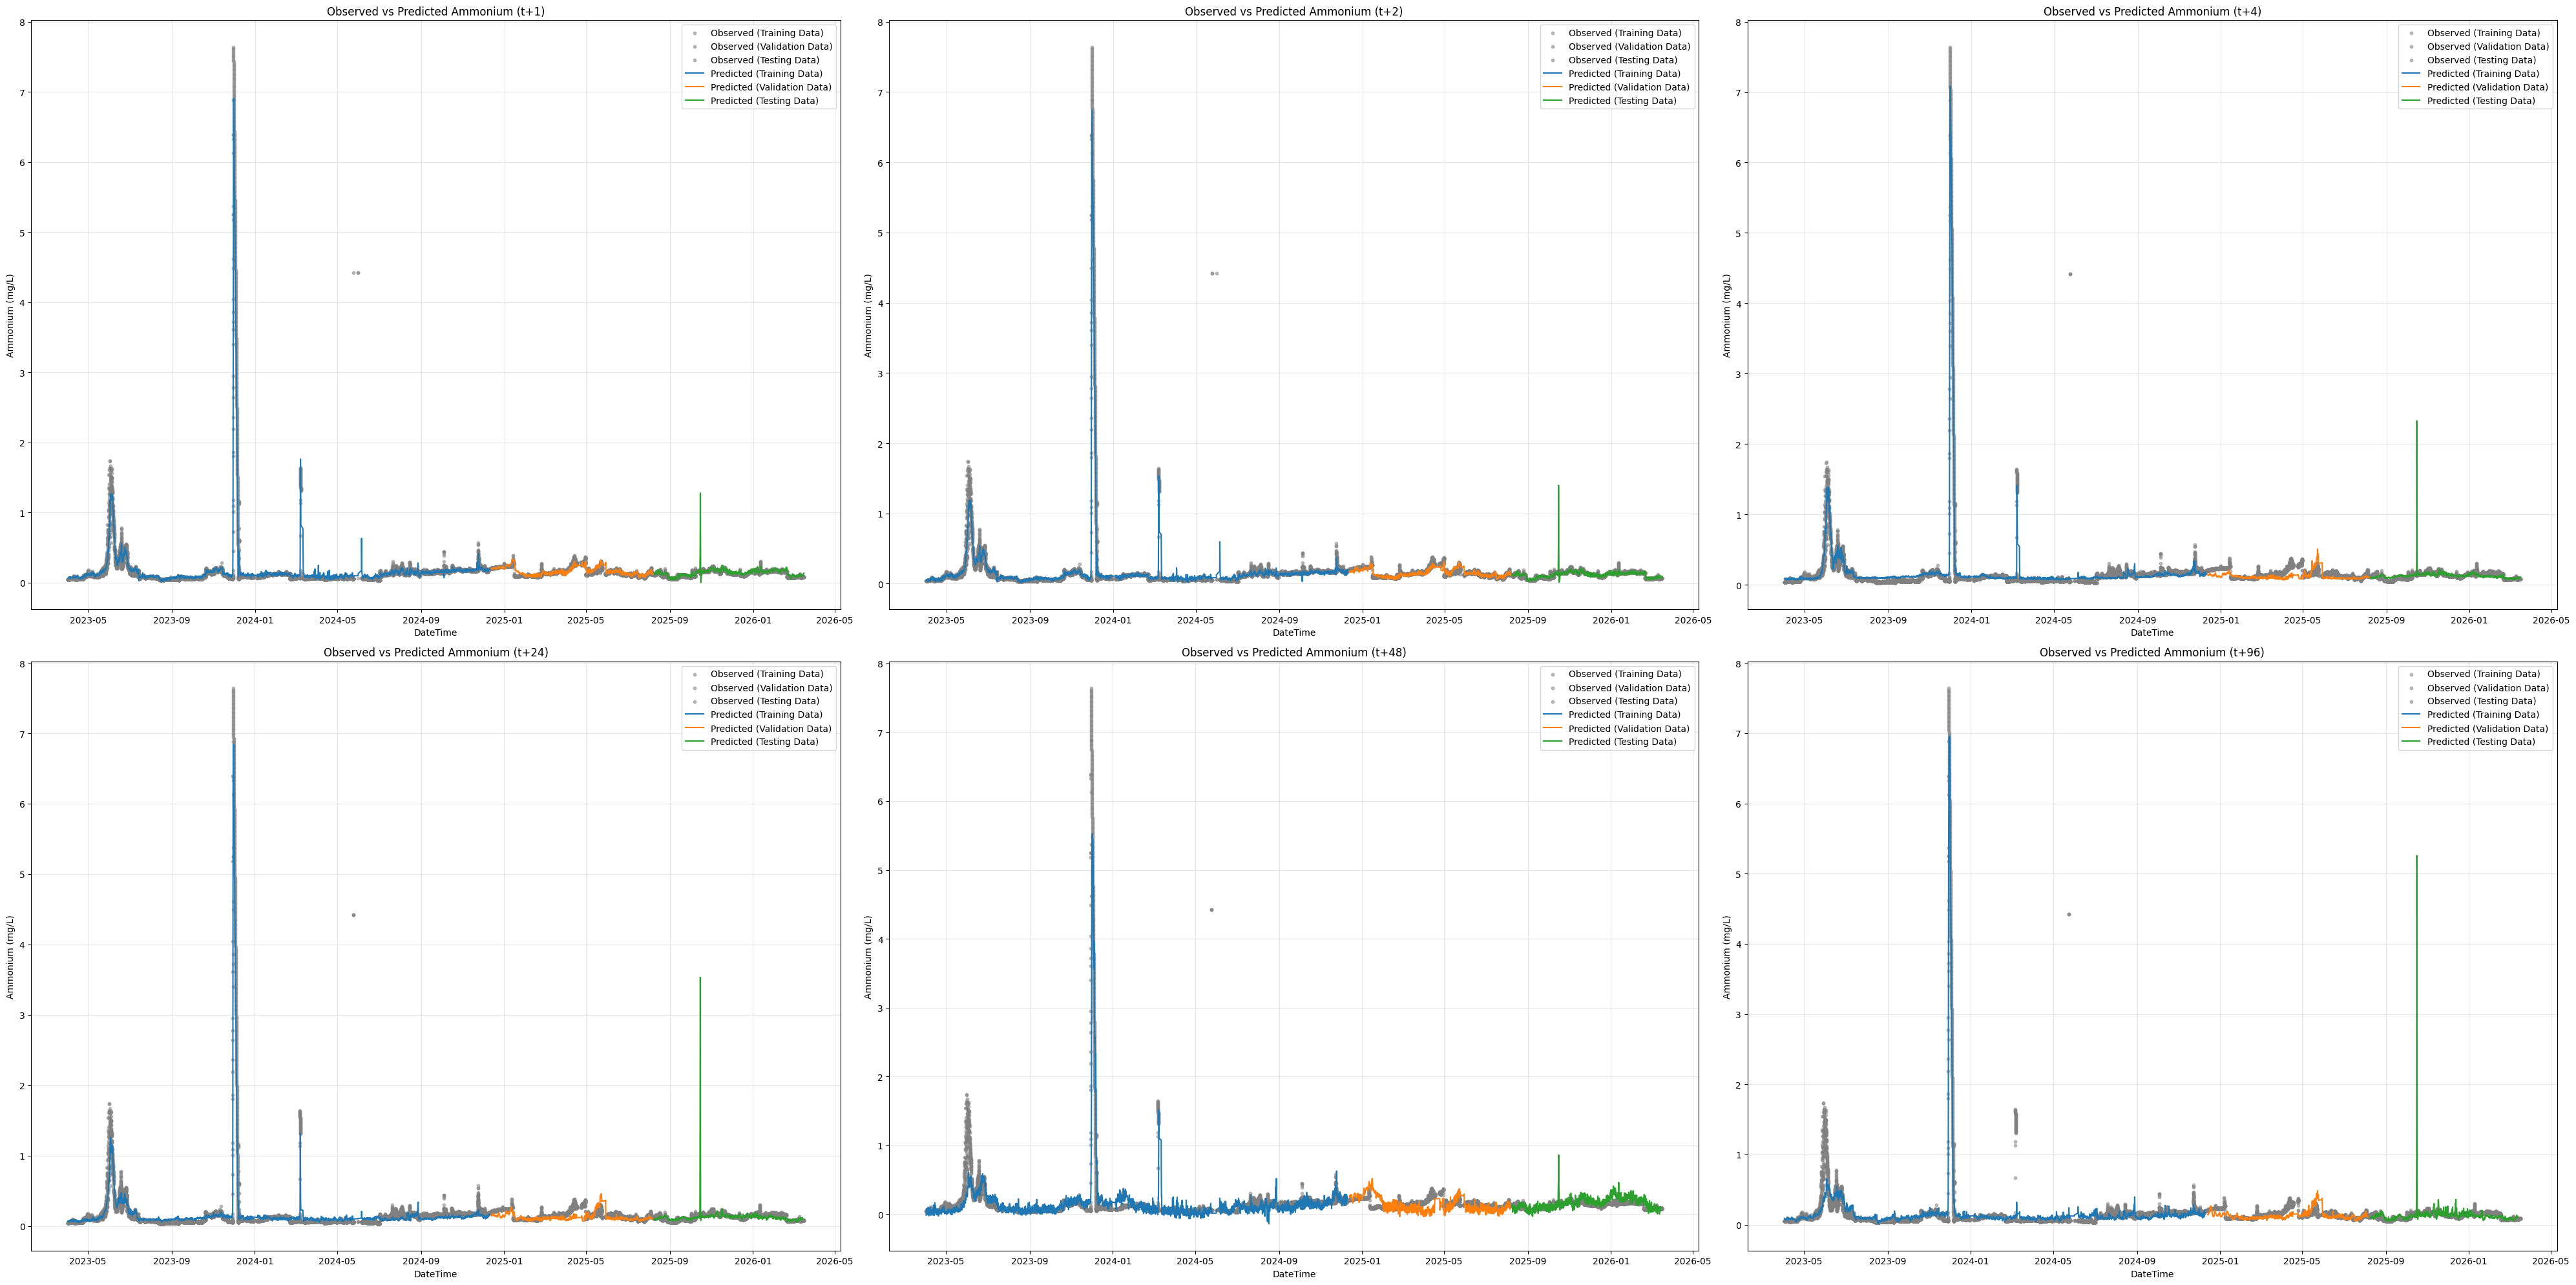

In [34]:
# Specify lookback window
LOOKBACK_WINDOW = 96 # 96 timesteps for 24hrs of 15min interval data

# Create a list of ammonium_targets
NUM_VARIABLES = 3 # 3 target variables: ammonium, dissolved oxygen, and temperature
ammonium_targets = targets[:int(len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(ammonium_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(ammonium_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    FORECAST_HORIZON = int(target.split('_')[-1])

    # Align timestamps with predictions and targets for x-axis plotting
    train_time_index = df_train.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    val_time_index   = df_val.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    test_time_index  = df_test.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))

    # Plot observed data
    ax.scatter(train_time_index[LOOKBACK_WINDOW:], y_train_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(val_time_index[LOOKBACK_WINDOW:], y_val_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(test_time_index[LOOKBACK_WINDOW:], y_test_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(train_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_train_dict[target][:-FORECAST_HORIZON], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(val_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_val_dict[target][:-FORECAST_HORIZON], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(test_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_test_dict[target][:-FORECAST_HORIZON], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Ammonium (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Ammonium (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

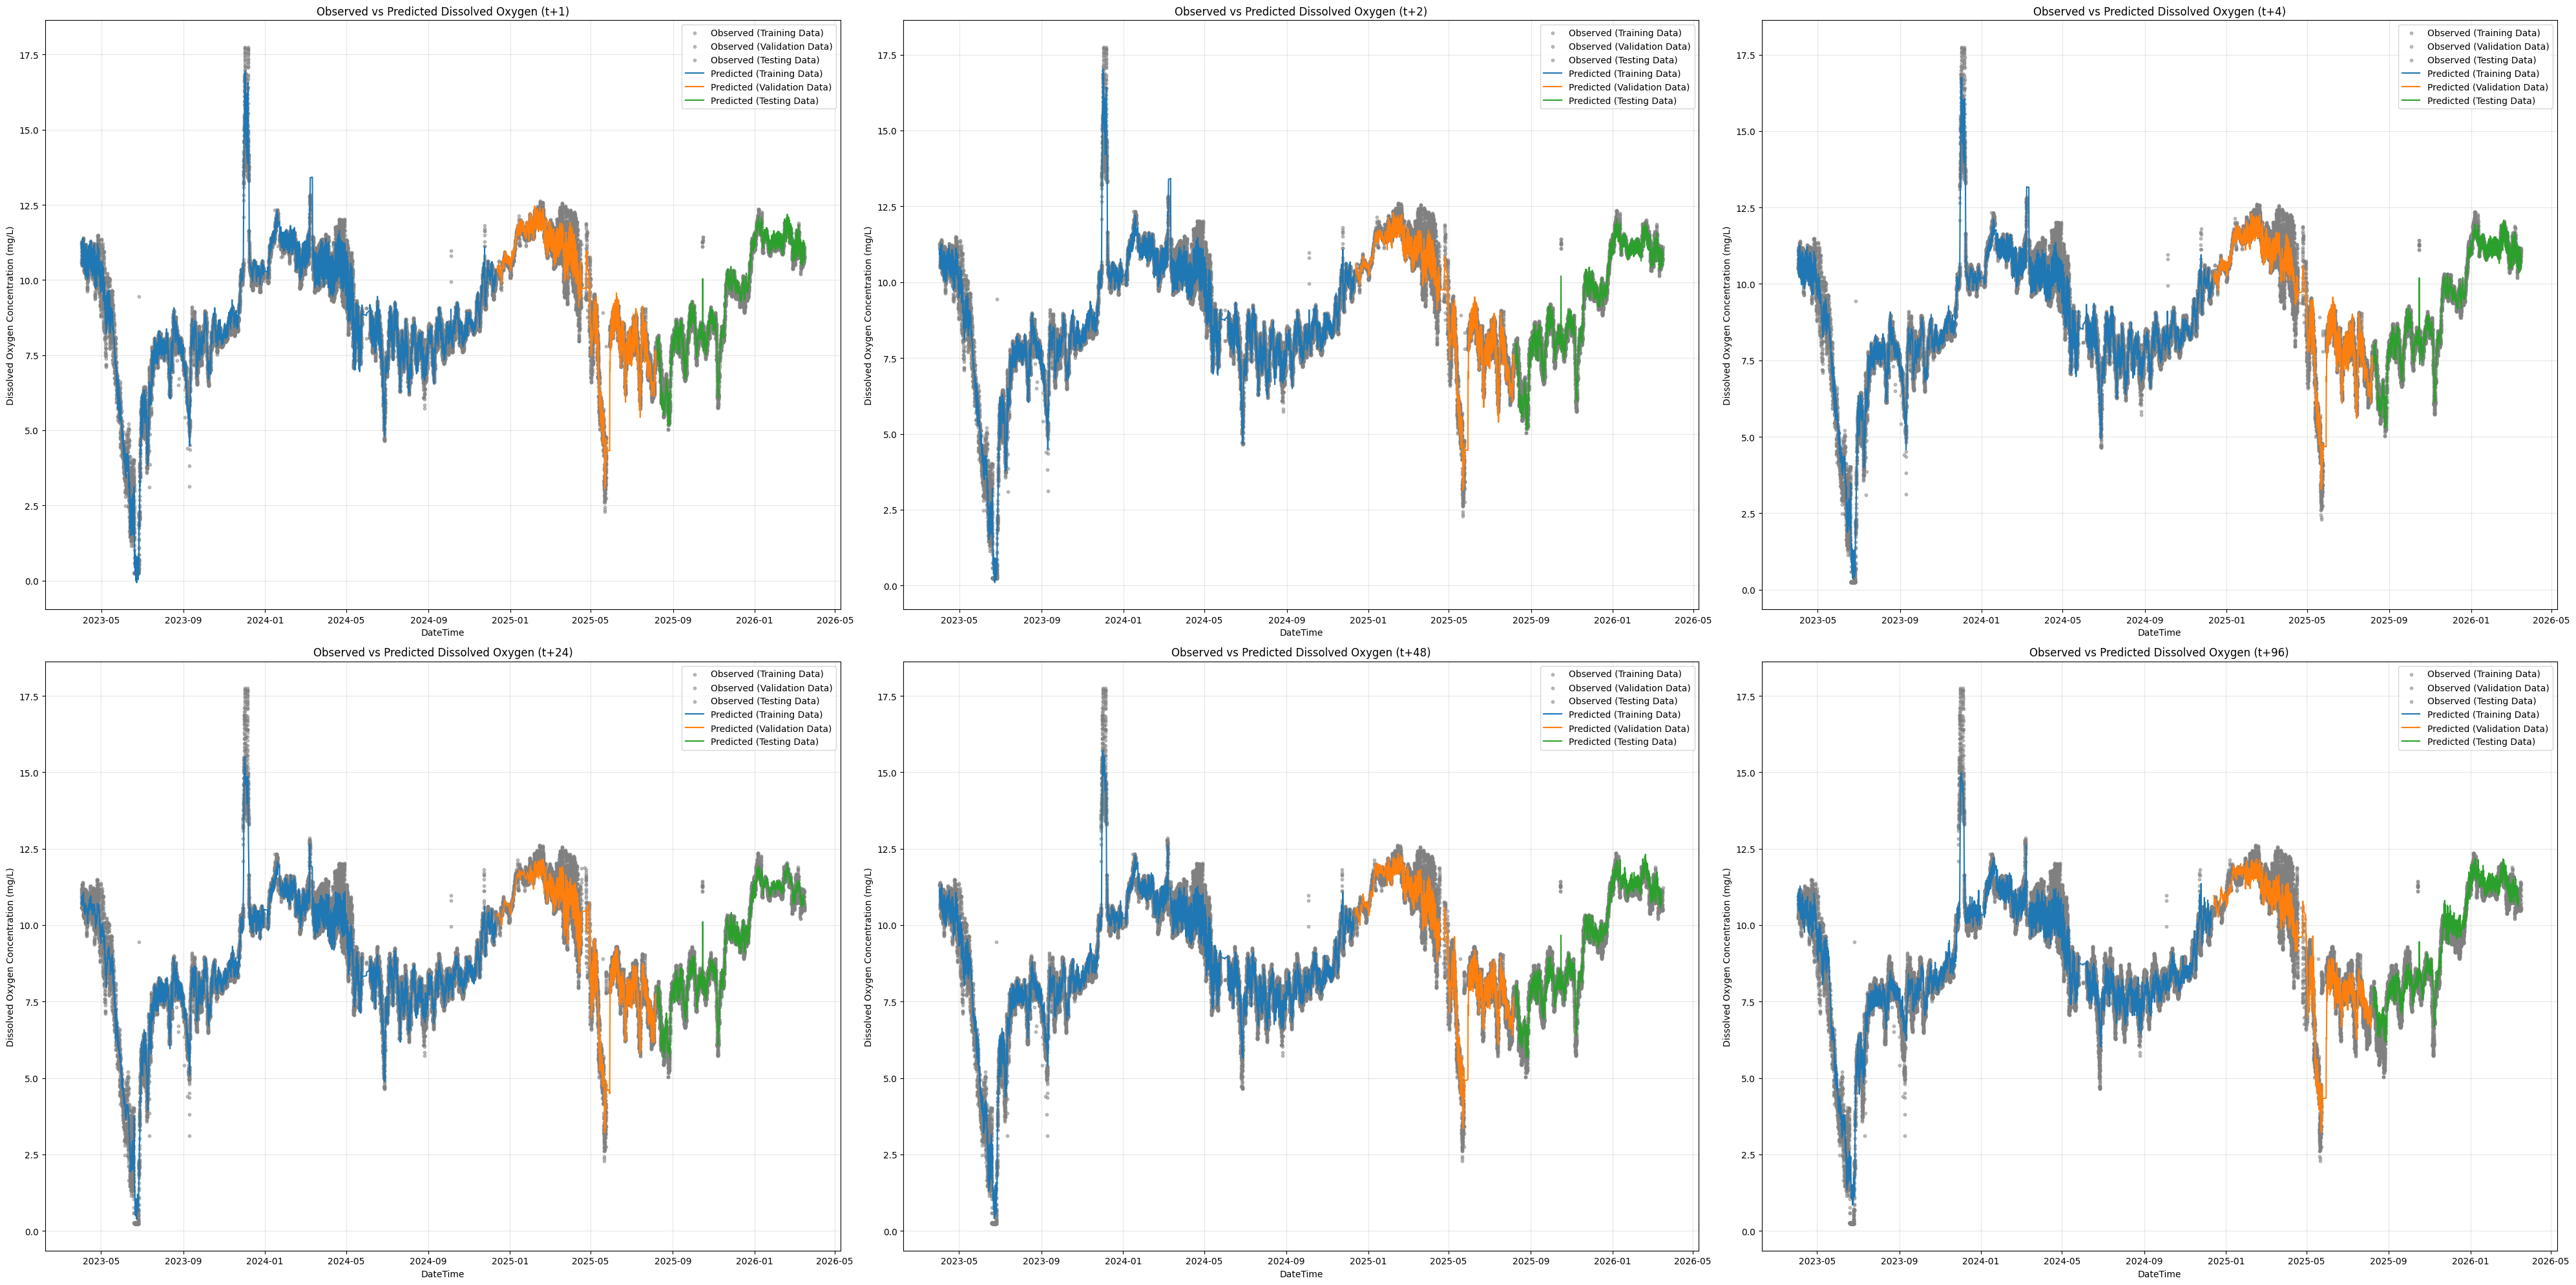

In [35]:
# Specify lookback window
LOOKBACK_WINDOW = 96 # 96 timesteps for 24hrs of 15min interval data

# Create a list of oxygen targets
NUM_VARIABLES = 3 # 3 target variables: ammonium, dissolved oxygen, and temperature
oxygen_targets = targets[int(len(targets)/3):int(2*len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(ammonium_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(oxygen_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    FORECAST_HORIZON = int(target.split('_')[-1])

    # Align timestamps with predictions and targets for x-axis plotting
    train_time_index = df_train.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    val_time_index   = df_val.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    test_time_index  = df_test.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))

    # Plot observed data
    ax.scatter(train_time_index[LOOKBACK_WINDOW:], y_train_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(val_time_index[LOOKBACK_WINDOW:], y_val_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(test_time_index[LOOKBACK_WINDOW:], y_test_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(train_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_train_dict[target][:-FORECAST_HORIZON], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(val_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_val_dict[target][:-FORECAST_HORIZON], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(test_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_test_dict[target][:-FORECAST_HORIZON], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Dissolved Oxygen (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Dissolved Oxygen Concentration (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

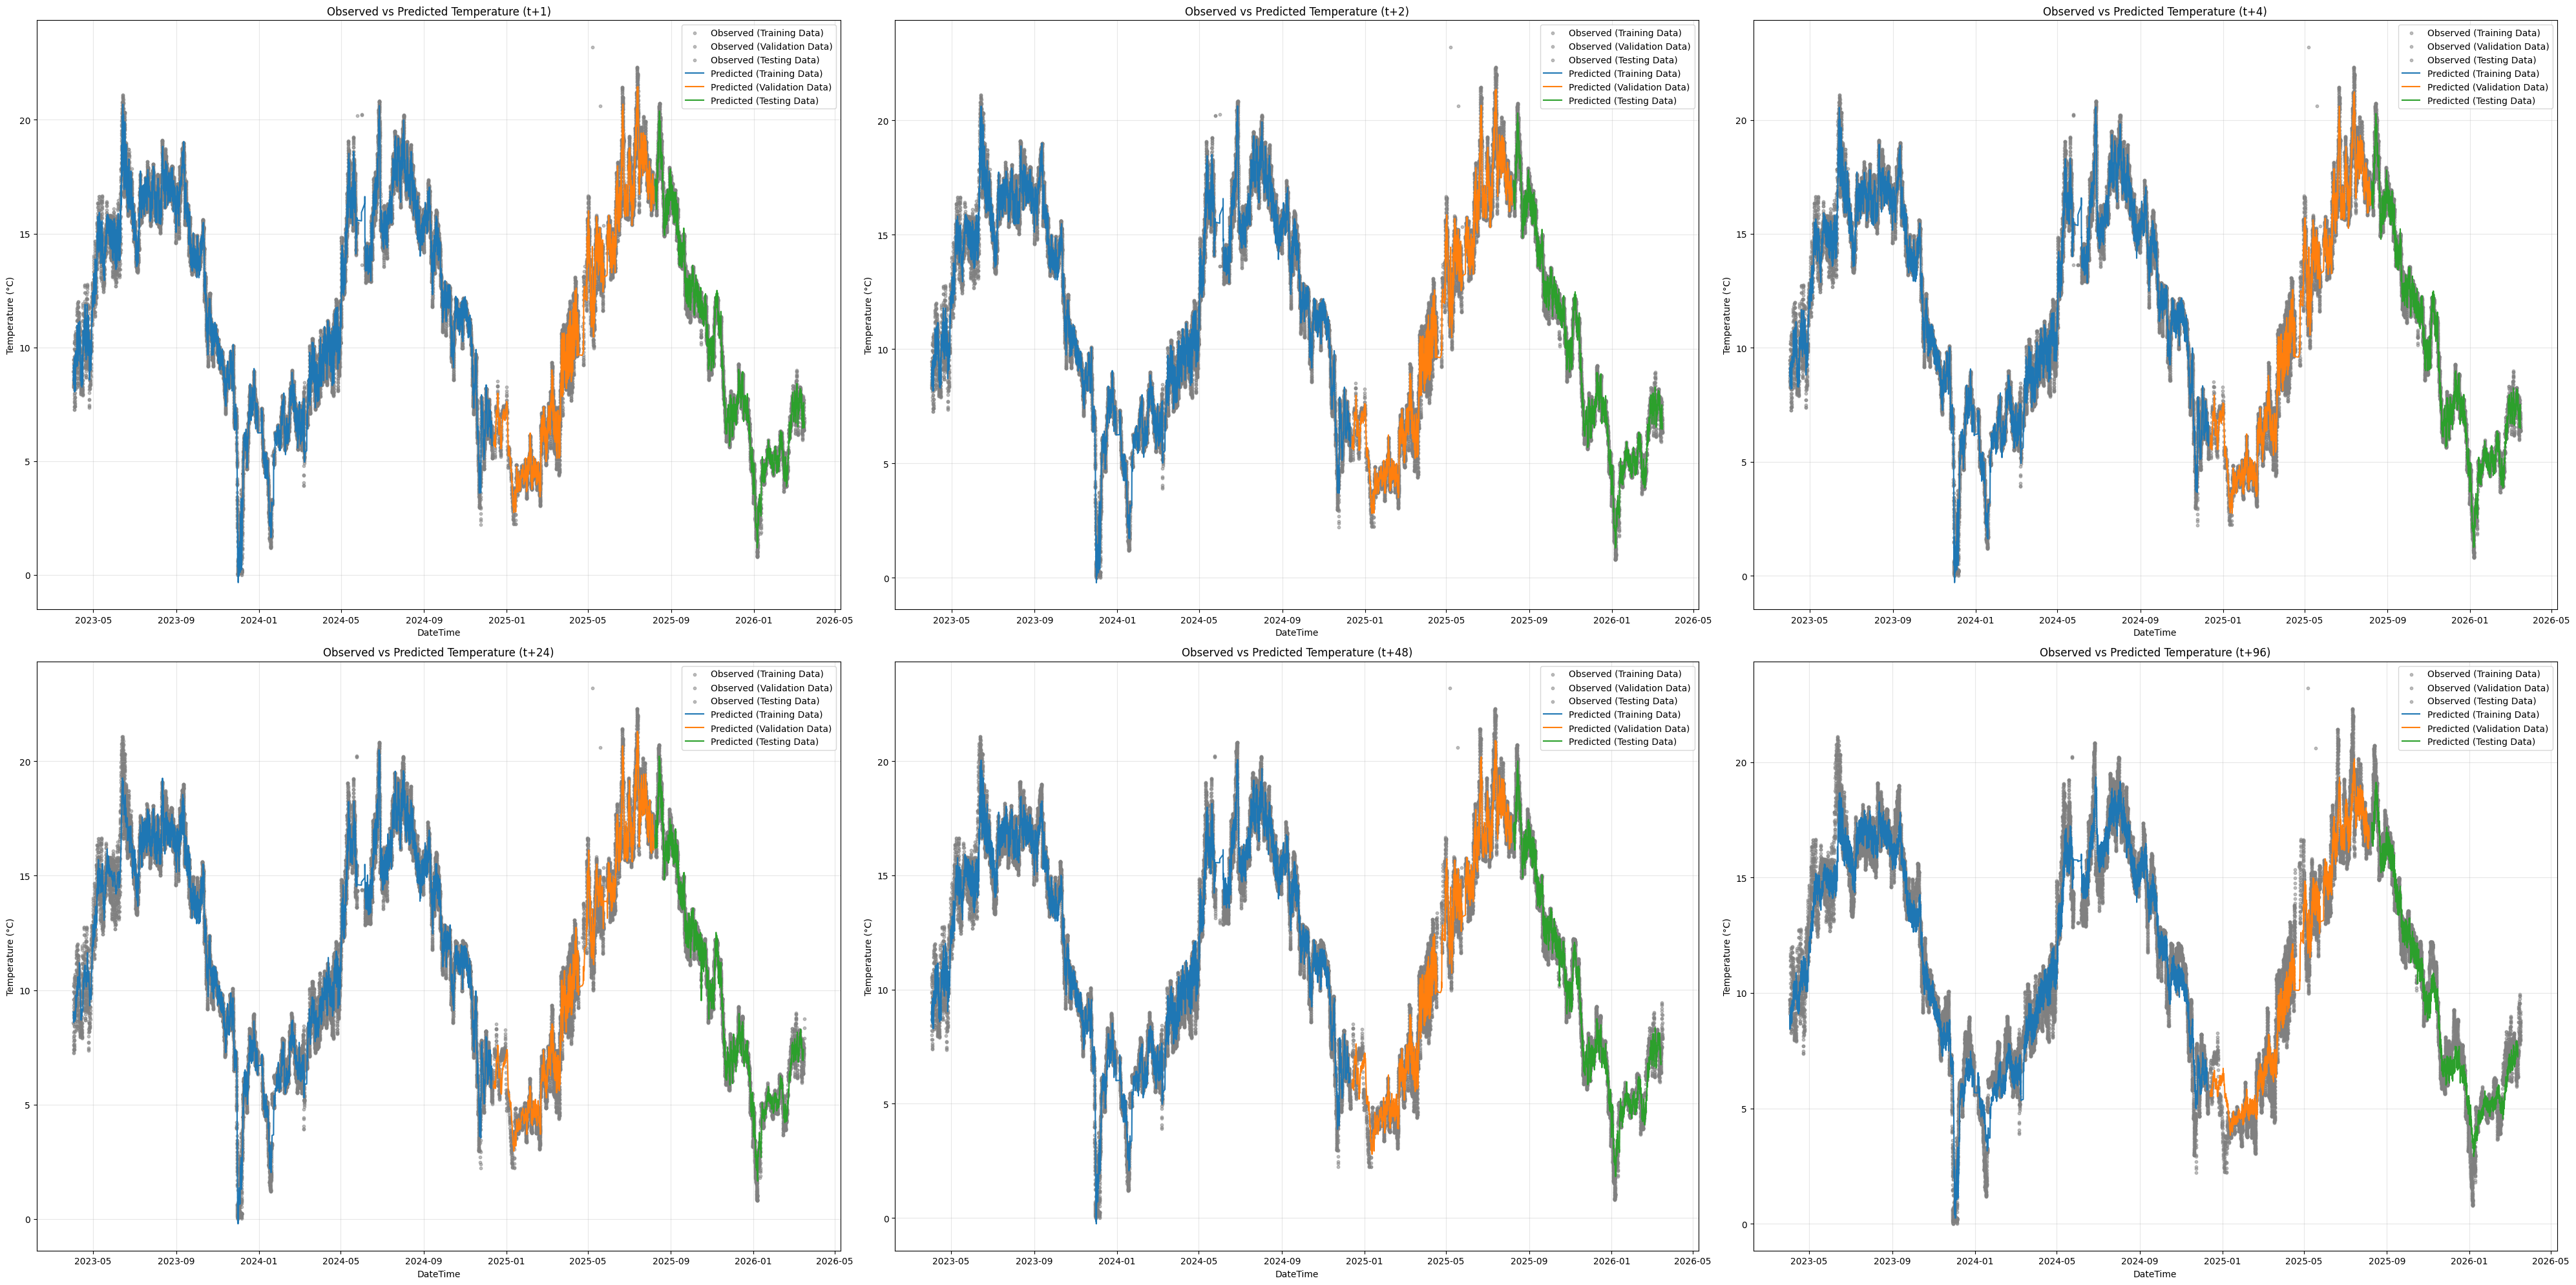

In [36]:
# Specify lookback window
LOOKBACK_WINDOW = 96 # 96 timesteps for 24hrs of 15min interval data

# Create a list of temperature_targets
NUM_VARIABLES = 3 # 3 target variables: ammonium, dissolved oxygen, and temperature
temperature_targets = targets[-int(len(targets)/3):]

# Create a figure and sets of axes to plot temperature predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(ammonium_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through temperature targets for plotting
for i, target in enumerate(temperature_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    FORECAST_HORIZON = int(target.split('_')[-1])

    # Align timestamps with predictions and targets for x-axis plotting
    train_time_index = df_train.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    val_time_index   = df_val.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))
    test_time_index  = df_test.index + pd.Timedelta(minutes=(FORECAST_HORIZON*15))

    # Plot observed data
    ax.scatter(train_time_index[LOOKBACK_WINDOW:], y_train_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(val_time_index[LOOKBACK_WINDOW:], y_val_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(test_time_index[LOOKBACK_WINDOW:], y_test_dict[target][LOOKBACK_WINDOW:], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(train_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_train_dict[target][:-FORECAST_HORIZON], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(val_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_val_dict[target][:-FORECAST_HORIZON], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(test_time_index[LOOKBACK_WINDOW:-FORECAST_HORIZON], y_pred_test_dict[target][:-FORECAST_HORIZON], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Temperature (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()